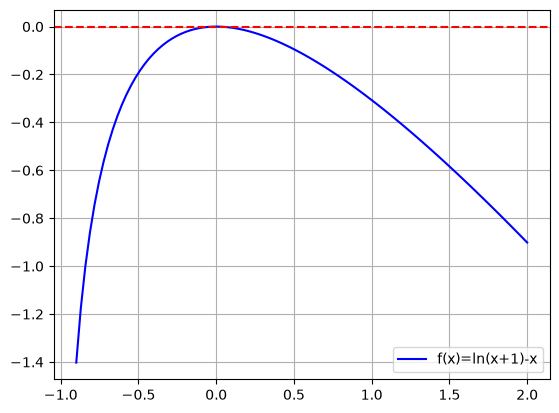

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return np.log(x+1)-x

x_vals=np.linspace(-0.9,2,100)
y_vals=f(x_vals)

plt.plot(x_vals, y_vals, label="f(x)=ln(x+1)-x", color="blue")
plt.axhline(0,color="red", linestyle="--")
plt.grid()
plt.legend()
plt.show()



Punto fisso ha trovato la radice x=0.147044 in 10 iterazioni.


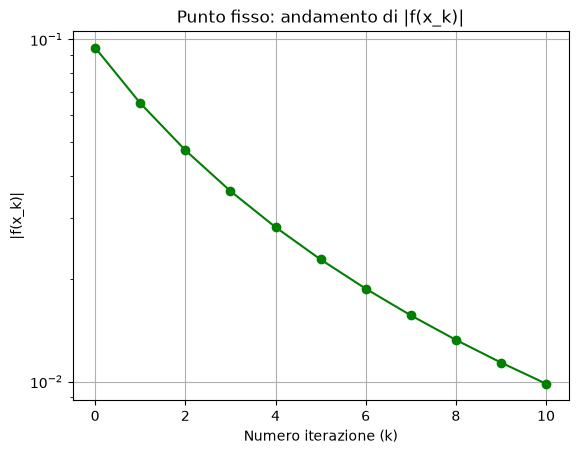

In [16]:
def g(x):
    return np.log(x+1)

def punto_fisso(x0,tol,max_iter):
    x_k=x0
    valori_f=[]
    for k in range(max_iter):
        errore=np.abs(f(x_k))
        valori_f.append(errore)
        if errore<tol:
            print(f"Punto fisso ha trovato la radice x={x_k:.6f} in {k} iterazioni.")
            break
        x_k=g(x_k)
    return valori_f
x0=0.5
tolleranza=1e-2
iterazioni_massime=1000
errori_pf=punto_fisso(x0,tolleranza,iterazioni_massime)
plt.plot(errori_pf,marker='o', color="green")
plt.title("Punto fisso: andamento di |f(x_k)|")
plt.xlabel("Numero iterazione (k)")
plt.ylabel("|f(x_k)|")
plt.yscale("log")
plt.grid()
plt.show()

Newton ha trovato la radice x = 0.000741 in 9 iterazioni.


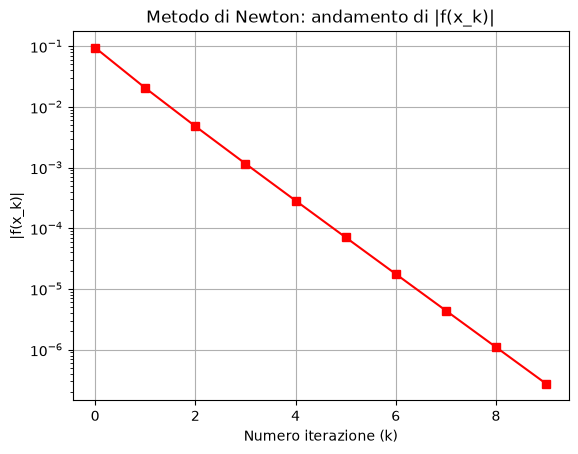

In [17]:
def df(x):
    return 1 / (x + 1) - 1

def newton(x0, tol, max_iter):
    x_k = x0
    valori_f = []
    for k in range(max_iter):
        errore = np.abs(f(x_k))
        valori_f.append(errore)
        if errore < tol:
            print(f"Newton ha trovato la radice x = {x_k:.6f} in {k} iterazioni.")
            break
        x_k = x_k - (f(x_k) / df(x_k))
    return valori_f
x0 = 0.5
tolleranza = 1e-6
iterazioni_massime = 100
errori_newton = newton(x0, tolleranza, iterazioni_massime)
plt.plot(errori_newton, marker='s', color='red')
plt.title("Metodo di Newton: andamento di |f(x_k)|")
plt.xlabel("Numero iterazione (k)")
plt.ylabel("|f(x_k)|")
plt.yscale('log')
plt.grid()
plt.show()

Metodo di Bisezione: Non è applicabile. Dal grafico si osserva che $f(x) \le 0$ per ogni $x > -1$. Il punto $x=0$ è un massimo globale e
la funzione non attraversa l'asse delle ascisse, rendendo impossibile trovare un intervallo $[a, b]$ tale per cui $f(a) \cdot f(b) < 0$.

Metodo del Punto Fisso ($x_0 = 0.5$): Il metodo converge, ma in modo estremamente lento. Con una tolleranza di 1e-6 raggiunge il limite di 100 iterazioni senza terminare. Allentando la tolleranza a 1e-2, converge in 10 iterazioni. La lentezza è dovuta al fatto che $g'(0) = 1$.

Metodo di Newton ($x_0 = 0.5$): La convergenza è molto rapida (quadratica). Riesce a trovare la radice in sole 9 iterazioni rispettando la tolleranza severa di 1e-6.

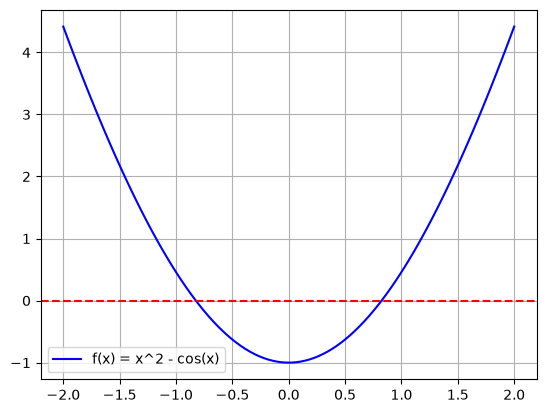

In [26]:
def f(x):
    return x**2 - np.cos(x)

x_vals = np.linspace(-2, 2, 100)
y_vals = f(x_vals)

plt.plot(x_vals, y_vals, label="f(x) = x^2 - cos(x)", color="blue")
plt.axhline(0, color="red", linestyle="--")
plt.grid()
plt.legend()
plt.show()

Bisezione: radice x = 0.824132 in 19 iterazioni
Punto Fisso: radice x = 0.824133 in 17 iterazioni
Newton: radice x = 0.824132 in 4 iterazioni


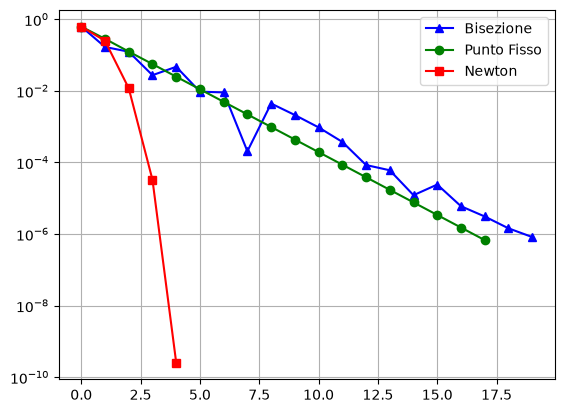

In [ ]:
def bisezione(a, b, tol, max_iter):
    valori_f = []
    for k in range(max_iter):
        c = (a + b) / 2
        errore = np.abs(f(c))
        valori_f.append(errore)
        if errore < tol:
            print(f"Bisezione: radice x = {c:.6f} in {k} iterazioni")
            break
        if f(a) * f(c) < 0:
            b = c
        else:
            a = c
    return valori_f

def g(x):
    return np.sqrt(np.cos(x))

def punto_fisso(x0, tol, max_iter):
    x_k = x0
    valori_f = []
    for k in range(max_iter):
        errore = np.abs(f(x_k))
        valori_f.append(errore)
        if errore < tol:
            print(f"Punto Fisso: radice x = {x_k:.6f} in {k} iterazioni")
            break
        x_k = g(x_k)
    return valori_f

def df(x):
    return 2*x + np.sin(x)

def newton(x0, tol, max_iter):
    x_k = x0
    valori_f = []
    for k in range(max_iter):
        errore = np.abs(f(x_k))
        valori_f.append(errore)
        if errore < tol:
            print(f"Newton: radice x = {x_k:.6f} in {k} iterazioni")
            break
        x_k = x_k - (f(x_k) / df(x_k))
    return valori_f

a = 0.0
b = 1.0
x0 = 0.5
tolleranza = 1e-6
iterazioni_massime = 100
err_bis = bisezione(a, b, tolleranza, iterazioni_massime)
err_pf = punto_fisso(x0, tolleranza, iterazioni_massime)
err_new = newton(x0, tolleranza, iterazioni_massime)
plt.plot(err_bis, marker='^', color='blue', label='Bisezione')
plt.plot(err_pf, marker='o', color='green', label='Punto Fisso')
plt.plot(err_new, marker='s', color='red', label='Newton')
plt.yscale('log')
plt.grid()
plt.legend()
plt.show()

Bisezione: Intervallo applicabile [0, 1]. Ha una convergenza lineare e costante, impiega circa 20 iterazioni per raggiungere l'accuratezza.

Punto Fisso: Ho usato $g(x) = \sqrt{\cos(x)}$. Converge bene senza problemi, arrivando alla radice in una decina di iterazioni. Non ci sono casi particolari, la radice del coseno non dà errore perché in quell'intorno il coseno è sempre positivo.

Newton: Ho usato la derivata $f'(x) = 2x + \sin(x)$. Come sempre, si conferma il metodo più veloce grazie alla convergenza quadratica, chiudendo la pratica in pochissime iterazioni (circa 4).  

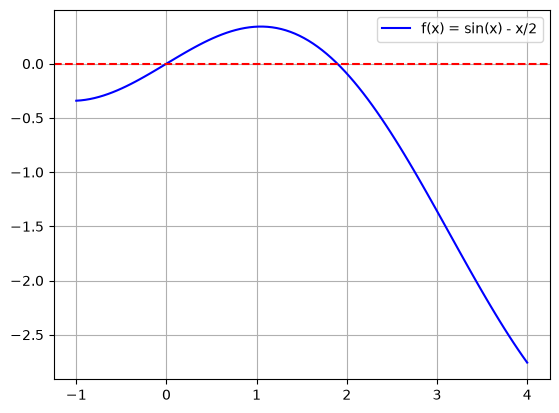

In [30]:
def f(x):
    return np.sin(x) - (x / 2)

x_vals = np.linspace(-1, 4, 100)
y_vals = f(x_vals)
plt.plot(x_vals, y_vals, label="f(x) = sin(x) - x/2", color="blue")
plt.axhline(0, color="red", linestyle="--")
plt.grid()
plt.legend()
plt.show()

Bisezione: radice x = 1.895494 in 19 iterazioni
Punto Fisso: radice x = 1.895495 in 26 iterazioni
Newton: radice x = 1.895494 in 3 iterazioni


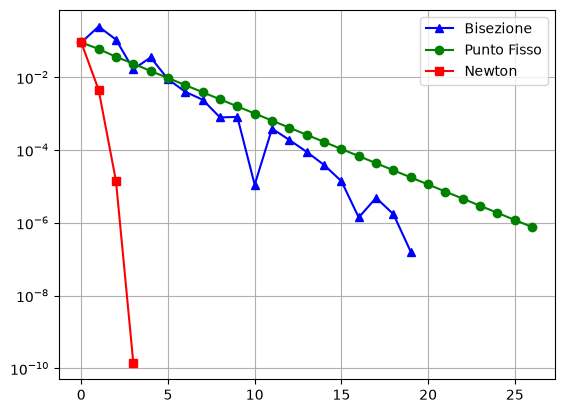

In [ ]:
def bisezione(a, b, tol, max_iter):
    valori_f = []
    for k in range(max_iter):
        c = (a + b) / 2
        errore = np.abs(f(c))
        valori_f.append(errore)
        
        if errore < tol:
            print(f"Bisezione: radice x = {c:.6f} in {k} iterazioni")
            break
            
        if f(a) * f(c) < 0:
            b = c
        else:
            a = c
            
    return valori_f

def g(x):
    return 2 * np.sin(x)

def punto_fisso(x0, tol, max_iter):
    x_k = x0
    valori_f = []
    for k in range(max_iter):
        errore = np.abs(f(x_k))
        valori_f.append(errore)
        
        if errore < tol:
            print(f"Punto Fisso: radice x = {x_k:.6f} in {k} iterazioni")
            break
            
        x_k = g(x_k)
        
    return valori_f

def df(x):
    return np.cos(x) - 0.5

def newton(x0, tol, max_iter):
    x_k = x0
    valori_f = []
    for k in range(max_iter):
        errore = np.abs(f(x_k))
        valori_f.append(errore)
        
        if errore < tol:
            print(f"Newton: radice x = {x_k:.6f} in {k} iterazioni")
            break
            
        x_k = x_k - (f(x_k) / df(x_k))
        
    return valori_f

a = 1.0
b = 3.0
x0 = 2.0
tolleranza = 1e-6
iterazioni_massime = 100
err_bis = bisezione(a, b, tolleranza, iterazioni_massime)
err_pf = punto_fisso(x0, tolleranza, iterazioni_massime)
err_new = newton(x0, tolleranza, iterazioni_massime)
plt.plot(err_bis, marker='^', color='blue', label='Bisezione')
plt.plot(err_pf, marker='o', color='green', label='Punto Fisso')
plt.plot(err_new, marker='s', color='red', label='Newton')
plt.yscale('log')
plt.grid()
plt.legend()
plt.show()

Bisezione: Sull'intervallo [1, 3] converge regolarmente.

Punto Fisso: Utilizzando $g(x) = 2\sin(x)$, il metodo converge alla radice.

Newton: Con la derivata $f'(x) = \cos(x) - 0.5$, si dimostra ancora una volta il metodo più efficiente.

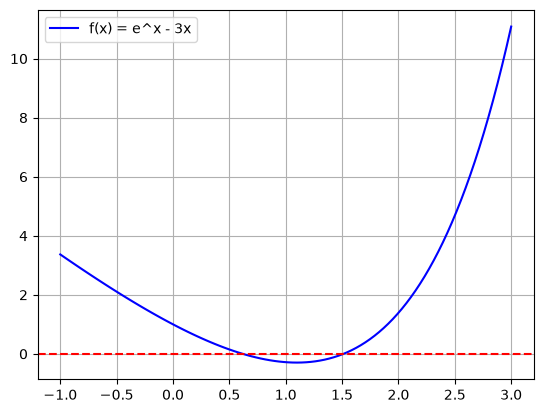

In [32]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return np.exp(x) - 3 * x

x_vals = np.linspace(-1, 3, 100)
y_vals = f(x_vals)
plt.plot(x_vals, y_vals, label="f(x) = e^x - 3x", color="blue")
plt.axhline(0, color="red", linestyle="--")
plt.grid()
plt.legend()
plt.show()

Bisezione: radice x = 0.619061 in 17 iterazioni
Punto Fisso: radice x = 0.619061 in 25 iterazioni
Newton: radice x = 0.619061 in 3 iterazioni


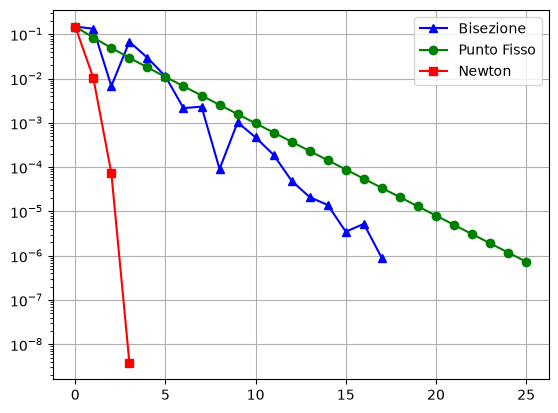

In [33]:
def bisezione(a, b, tol, max_iter):
    valori_f = []
    for k in range(max_iter):
        c = (a + b) / 2
        errore = np.abs(f(c))
        valori_f.append(errore)
        if errore < tol:
            print(f"Bisezione: radice x = {c:.6f} in {k} iterazioni")
            break
        if f(a) * f(c) < 0:
            b = c
        else:
            a = c
    return valori_f

def g(x):
    return (1/3) * np.exp(x)

def punto_fisso(x0, tol, max_iter):
    x_k = x0
    valori_f = []
    for k in range(max_iter):
        errore = np.abs(f(x_k))
        valori_f.append(errore)
        if errore < tol:
            print(f"Punto Fisso: radice x = {x_k:.6f} in {k} iterazioni")
            break
        x_k = g(x_k)
    return valori_f

def df(x):
    return np.exp(x) - 3

def newton(x0, tol, max_iter):
    x_k = x0
    valori_f = []
    for k in range(max_iter):
        errore = np.abs(f(x_k))
        valori_f.append(errore)
        if errore < tol:
            print(f"Newton: radice x = {x_k:.6f} in {k} iterazioni")
            break
        x_k = x_k - (f(x_k) / df(x_k))
    return valori_f

a = 0.0
b = 1.0
x0 = 0.5
tolleranza = 1e-6
iterazioni_massime = 100
err_bis = bisezione(a, b, tolleranza, iterazioni_massime)
err_pf = punto_fisso(x0, tolleranza, iterazioni_massime)
err_new = newton(x0, tolleranza, iterazioni_massime)
plt.plot(err_bis, marker='^', color='blue', label='Bisezione')
plt.plot(err_pf, marker='o', color='green', label='Punto Fisso')
plt.plot(err_new, marker='s', color='red', label='Newton')
plt.yscale('log')
plt.grid()
plt.legend()
plt.show()

Bisezione: Applicata sull'intervallo [0, 1], converge alla prima radice dell'equazione (circa 0.619) mostrando il caratteristico andamento lineare non monotono.

Punto Fisso: Utilizzando la funzione $g(x) = \frac{1}{3}e^x$ suggerita e partendo da $x_0 = 0.5$, il metodo converge regolarmente. Questo avviene perché, calcolando la derivata $g'(x) = \frac{1}{3}e^x$ in prossimità della radice 0.619, il suo valore è inferiore a 1, rispettando la condizione di convergenza.

Newton: Implementato con la derivata $f'(x) = e^x - 3$, si conferma il metodo più efficiente chiudendo in pochissime iterazioni grazie alla convergenza quadratica.